c: that means :
the yi point lies  above the y_line(xi)
the yi point lies  under the y_line(xi)
group 1 those points that are above the y_line
group 0 those points that are under the y_line

VG:
slope=k
intercept=m:(x_data+ y_data)
y_line= (k*x)+m 

ii) 

In the first y_line my slope and intercept is flixible. If i dont have any intercept program will automatically calculate from my data(x_data+ y_data). I choose slope -1 becouse it gives me a downward 45 line.
y_line: 300.0 points above, 300.0 under

In the f(x)line, the slope(k) is given= 0.489, intercept will be calculated automatically from the  given data.
f_line: 301.0 points above, 299.0 under

In the g(x)line, the slope (k) is given -2 and intercept is 0.16 wich is solid.
g_line: 301.0 points above, 299.0 under

In the h(x)line, the slope is more higher the number of slope we have in data 800 and slope minus 120 So at x = 0, the line starts below the x-axis at −120. But since the slope (800) is very steep, it climbs upward extremely fast.h_line: 302.0 points above, 298.0 under

iii) It really depend on what goal we have.infinitively many lines depent on our informations.




Above: [[2.0903622  2.56248995]
 [2.89580016 2.43545756]
 [1.74903383 3.1693298 ]
 [2.31292302 0.49425589]
 [2.79189149 3.85670733]]
Below: [[-1.88590752 -1.9974076 ]
 [-2.92822068  0.08238728]
 [-2.35896415 -1.03842905]
 [-2.9322204  -1.76631279]
 [-1.69706855 -2.57372455]]


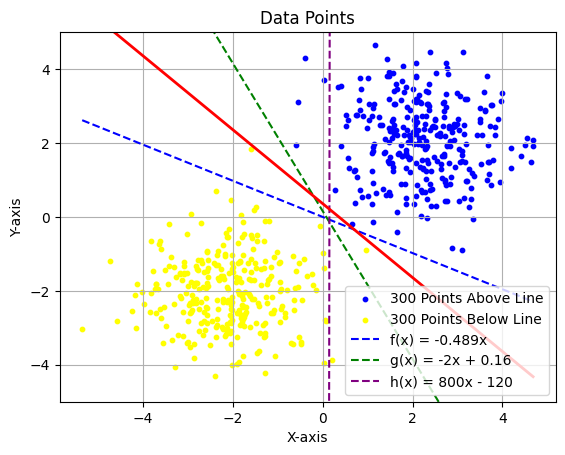

y_line: 300.0 points above, 300.0 under
f_line: 301.0 points above, 299.0 under
g_line: 301.0 points above, 299.0 under
h_line: 302.0 points above, 298.0 under


In [ ]:
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import csv


#download data
data_url="https://raw.githubusercontent.com/Horieh1989/lab3/refs/heads/master/Datas/unlabelled_data.csv"
try:
    urllib.request.urlretrieve(data_url, "unlabelled_data.csv")
except Exception as e:
    print(f"Fail to download datapoints.txt: {e}")


#open data in a list
response = urllib.request.urlopen(data_url)
lines = [line.decode('utf-8') for line in response]  # decode bytes to string
csv_reader = csv.reader(lines)#csv_reader is an irritator
x_data=[]
y_data=[]

for row in csv_reader:
    x_data.append(float(row[0]))#colimns[0]
    y_data.append(float(row[1]))#columns[1]
    
x_data=np.array(x_data)
y_data=np.array(y_data)


#generate x for the lines    
x = np.linspace(np.min(x_data), np.max(x_data))

#main line
def y_line(x,k=-1,m=None):#main line
    if m is None:
        m=np.median(x_data+ y_data)
    return k * x + m
 
def f_line(x): #VG
    return -0.489 * x

def g_line(x): #VG
    return -2 * x + 0.16

def h_line(x): #VG
    return 800 * x - 120



#calculate the split line(main line)    
def calculate_split_line(x_data,y_data):
    k=-1
    m=np.median(x_data+ y_data)
    x_values= np.array([np.min(x_data),np.max(x_data)])
    y=y_line( x_values,k ,m)
    
    return x_values, y,m, k

x_values,y,m,k=calculate_split_line(x_data,y_data)


#list the points above and under the line
def list_point(x_data,y_data,k,m):
    y_line_values=y_line(x_data,k ,m)
    above_list=[(x_data[i],y_data[i])for i in range(len(x_data)) if y_data[i]>  y_line_values[i] ]
    under_list=[(x_data[i],y_data[i]) for i in range(len(x_data)) if y_data[i] <  y_line_values[i]]
 
    return np.array(above_list), np.array(under_list)

#test the list just the firs 5
above, below = list_point(x_data, y_data, k, m)
print("Above:", above[:5])  # show first 5
print("Below:", below[:5])


#write in csv file
def Csv_file(above_list,under_list):
    with open ("labelled_data.csv" ,"w") as file:
        for dot in above_list:
            file.write(f"{dot[0]},{dot[1]},1\n")
        for dot in under_list:
            file.write(f"{dot[0]},{dot[1]},0\n")
            
            
#compare the classifications of the lines with the main line(y_line function)
def compare_classifications(x_data, y_data, line_functions):#VG
    results = {}
    for name, func in line_functions.items():
        labels = (y_data > func(x_data)).astype(float)
        results[name] = labels
        print(f"{name}: {np.sum(labels)} points above, {len(labels) - np.sum(labels)} under")
    return results

line_funcs = {"y_line": lambda x: y_line(x, k, m),
              "f_line": f_line,
              "g_line": g_line,
              "h_line": h_line}

classifications = compare_classifications(x_data, y_data, line_funcs)

# Plot data dotss(above and under the line) and lines
def plot_data(above_list, under_list, x_values, y):
    plt.scatter(above_list[:, 0], above_list[:, 1], s=10, color="blue", label=f"{len(above_list)} Points Above Line")
    plt.scatter(under_list[:, 0], under_list[:, 1], s=10, color="yellow", label=f"{len(under_list)} Points Below Line")
   

    # Plot each line
    plt.plot(x,y_line(x,k,m), color="red", label="Original Line (y_line)")
    plt.plot(x, f_line(x), color="blue", linestyle="--", label="f(x) = -0.489x")#VG
    plt.plot(x, g_line(x), color="green", linestyle="--", label="g(x) = -2x + 0.16")#VG
    plt.plot(x, h_line(x), color="purple", linestyle="--", label="h(x) = 800x - 120")#VG
    plt.plot(x_values, y, color="r", linewidth=2)

    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title(f"Data Points")
    plt.legend()
    plt.grid()
    plt.ylim(-5, 5)#VG
    plt.show()
    
#call the functions   
Csv_file(above, below)
plot_data(above, below, x_values, y)



 




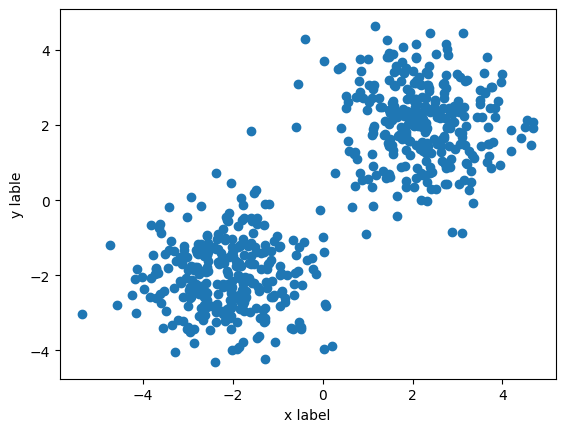

[]

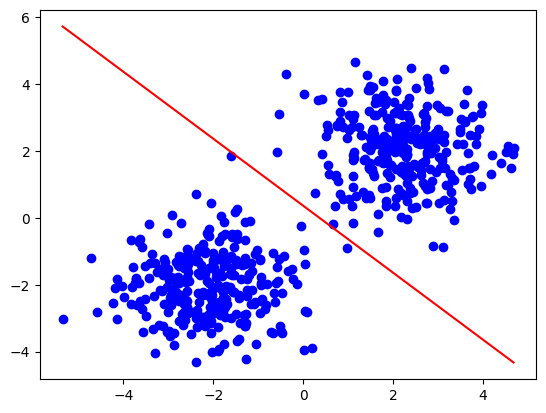

In [1]:
import urllib
import csv
import numpy as np
import matplotlib.pyplot as plt


data_url="https://raw.githubusercontent.com/Horieh1989/lab3/refs/heads/master/Datas/unlabelled_data.csv"

#download data
try:
    urllib.request.urlretrieve(data_url, "unlabelled_data.csv")
except Exception as e:
    print(f"Fail to download datapoints.txt: {e}")

#open data in a list
response = urllib.request.urlopen(data_url)
lines = [line.decode('utf-8') for line in response]  # decode bytes to string
csv_reader = csv.reader(lines)#csv_reader is an irritator
#for row in csv_reader:
    #print(row)#if you want to see list
    
x_data=[]
y_data=[]

for raw in csv_reader:
    x_data.append(float(raw[0]))#colum0
    y_data.append(float(raw[1]))#colum1
 
 
 #change to array here
x_data=np.array(x_data)
y_data=np.array(y_data)

plt.scatter(x_data,y_data)
plt.xlabel("x label")
plt.ylabel("y lable")
plt.show()


#slope =  k # A slope of -1 gives a 45° downward line.
#intercept = m =(x+y)


#intercept= x_data+y_data
#middle_value=np.median(intercept)
#(y = kx + m)
def y_line(x,slope,intercept):
   return slope*x+intercept
    


def calculate_linje(x_data,y_data):
    slope=-1
    intercept=np.median(x_data + y_data)
    x_values= np.array([np.min(x_data),np.max(x_data)])
    y_values=y_line(x_values,slope,intercept)
     
    return x_values,y_values,intercept

x_values,y_values,intercept=calculate_linje(x_data,y_data)

plt.scatter(x_data,y_data, color="blue",label="datapoint")
plt.plot(x_values,y_values,color="red" ,label="spliting line")

 
 
 
 
 
 
 
 
 
k=-1
m=0
 
x = np.linspace(np.min(x_data), np.max(x_data))
def original_line(x):
     return k * x + m
 
def f_line(x):
    return -0.489 * x

def g_line(x):
    return -2 * x + 0.16

def h_line(x):
    return 800 * x - 120






plt.plot()

 

In [12]:
import numpy as np

# Example x_data and y_data
x_data = np.array([1, 2, 3, 4])
y_data = np.array([5, 6, 7, 8])

# Sum element-wise
sum_xy = x_data + y_data

# Compute the median
middle_value = np.median(sum_xy)

print(f"Separated data: {sum_xy}")
print(f"Median (intercept): {middle_value}")


Separated data: [ 6  8 10 12]
Median (intercept): 9.0
